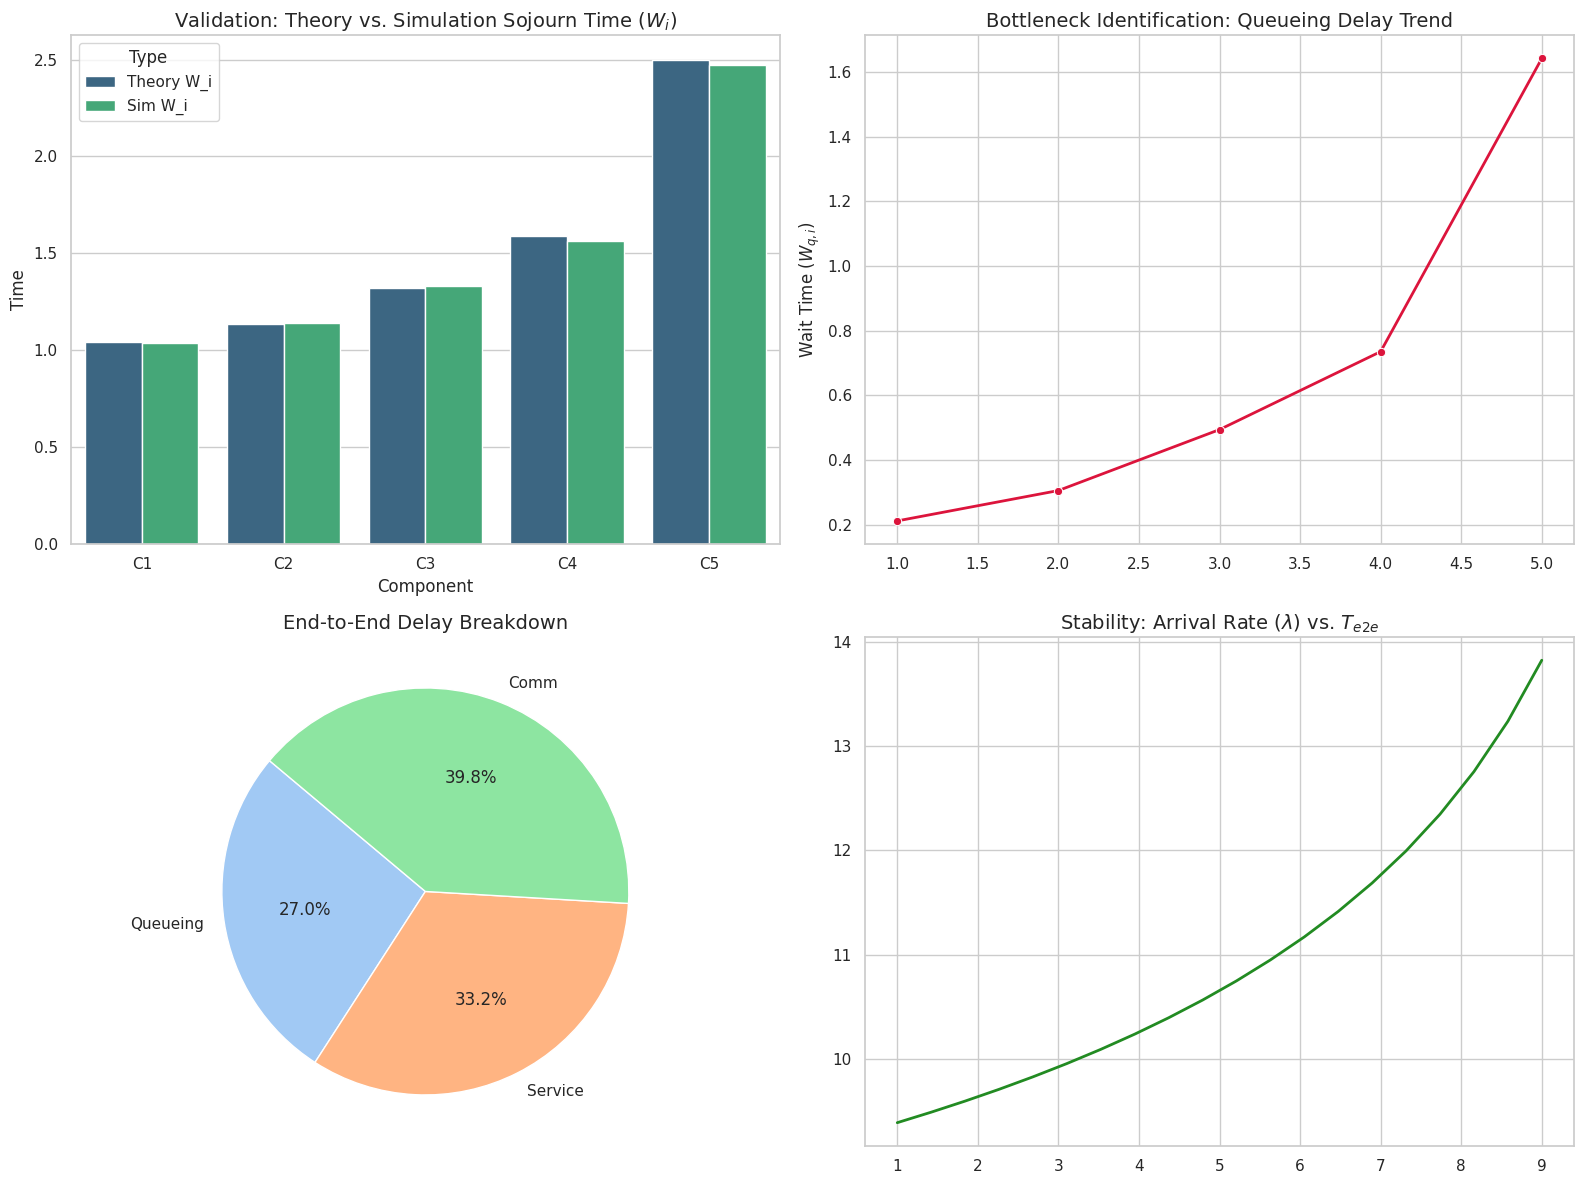

Component  Theory W_i  Sim W_i  Theory Wq_i  Sim Wq_i  Theory L_i  Sim L_i
       C1    1.044304 1.039187     0.210970  0.211285    0.253165 0.251924
       C2    1.136364 1.139454     0.303030  0.305250    0.363636 0.364625
       C3    1.323529 1.329575     0.490196  0.493896    0.588235 0.590922
       C4    1.590909 1.561263     0.757576  0.735217    0.909091 0.892150
       C5    2.500000 2.474238     1.666667  1.642500    2.000000 1.979390


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1) COMPONENT PLACEMENT MODEL
# ============================================================
def geometric_component_shares(num_components: int, ratio: float) -> np.ndarray:
    if not (0 < ratio < 1):
        raise ValueError("ratio must satisfy 0 < r < 1")

    component_shares = np.array(
        [
            (1 - ratio) * (ratio**i) / (1 - ratio**num_components)
            for i in range(num_components)
        ],
        dtype=float,
    )
    return component_shares


def allocate_hosts(total_devices: int, component_shares: np.ndarray) -> np.ndarray:
    raw_counts = np.rint(total_devices * component_shares).astype(int)
    raw_counts = np.maximum(raw_counts, 1)
    difference = total_devices - raw_counts.sum()
    order = np.argsort(-component_shares)

    index = 0
    while difference != 0:
        component_index = order[index % len(order)]
        if difference > 0:
            raw_counts[component_index] += 1
            difference -= 1
        else:
            if raw_counts[component_index] > 1:
                raw_counts[component_index] -= 1
                difference += 1
        index += 1
    return raw_counts


# ============================================================
# 2) ANALYTICAL FORMULAS
# ============================================================
def compute_theoretical_metrics(
    total_devices: int,
    num_components: int,
    geometric_ratio: float,
    arrival_rate: float,
    service_rates: np.ndarray,
    source_delay: float,
    inter_component_delays: np.ndarray,
):
    component_shares = geometric_component_shares(num_components, geometric_ratio)
    host_counts = allocate_hosts(total_devices, component_shares)

    arrival_rate_per_host = arrival_rate / host_counts
    utilization = arrival_rate_per_host / service_rates

    sojourn_time = 1.0 / (service_rates - arrival_rate_per_host)
    queue_wait_time = sojourn_time - (1.0 / service_rates)

    avg_number_in_system = utilization / (1.0 - utilization)
    avg_queue_length = avg_number_in_system - utilization

    total_queue_delay = queue_wait_time.sum()
    total_service_time = np.sum(1.0 / service_rates)
    total_comm_delay = source_delay + inter_component_delays.sum()

    total_end_to_end_delay = total_queue_delay + total_service_time + total_comm_delay

    return {
        "component_shares": component_shares,
        "host_counts": host_counts,
        "arrival_rate_per_host": arrival_rate_per_host,
        "utilization": utilization,
        "sojourn_time": sojourn_time,
        "queue_wait_time": queue_wait_time,
        "avg_number_in_system": avg_number_in_system,
        "avg_queue_length": avg_queue_length,
        "total_queue_delay": total_queue_delay,
        "total_service_time": total_service_time,
        "total_comm_delay": total_comm_delay,
        "total_end_to_end_delay": total_end_to_end_delay,
    }


# ============================================================
# 3) M/M/1 SIMULATION FOR ONE COMPONENT
# ============================================================
def simulate_mm1_queue(
    arrival_rate: float,
    service_rate: float,
    num_jobs: int = 50000,
    warmup_jobs: int = 5000,
    random_seed: int = 1,
):
    if arrival_rate >= service_rate:
        raise ValueError("Queue is unstable")

    rng = np.random.default_rng(random_seed)
    arrival_times = np.cumsum(rng.exponential(scale=1.0 / arrival_rate, size=num_jobs))
    service_times = rng.exponential(scale=1.0 / service_rate, size=num_jobs)

    start_service_times = np.zeros(num_jobs)
    departure_times = np.zeros(num_jobs)
    waiting_times = np.zeros(num_jobs)
    system_times = np.zeros(num_jobs)

    server_available_time = 0.0
    for i in range(num_jobs):
        start_service_times[i] = max(arrival_times[i], server_available_time)
        waiting_times[i] = start_service_times[i] - arrival_times[i]
        departure_times[i] = start_service_times[i] + service_times[i]
        system_times[i] = departure_times[i] - arrival_times[i]
        server_available_time = departure_times[i]

    effective_waiting_times = waiting_times[warmup_jobs:]
    effective_system_times = system_times[warmup_jobs:]

    return {
        "sim_W": np.mean(effective_system_times),
        "sim_Wq": np.mean(effective_waiting_times),
        "sim_L": arrival_rate * np.mean(effective_system_times),
        "sim_Lq": arrival_rate * np.mean(effective_waiting_times),
    }


# ============================================================
# 4) FULL EVALUATION & VISUALIZATION
# ============================================================
def run_evaluation_with_plots():
    # Parameters
    total_devices = 100
    num_components = 5
    geometric_ratio = 0.75
    global_arrival_rate = 8.0
    service_rates = np.array([1.2] * 5, dtype=float)
    source_to_first_delay = 1.0
    inter_comp_delays = np.array([1.0] * 4, dtype=float)

    # Theory
    theory = compute_theoretical_metrics(
        total_devices, num_components, geometric_ratio,
        global_arrival_rate, service_rates, source_to_first_delay, inter_comp_delays
    )

    # Simulation
    sim_W, sim_Wq, sim_L, sim_Lq = [], [], [], []
    for idx in range(num_components):
        res = simulate_mm1_queue(theory["arrival_rate_per_host"][idx], service_rates[idx], random_seed=idx+1)
        sim_W.append(res["sim_W"]); sim_Wq.append(res["sim_Wq"])
        sim_L.append(res["sim_L"]); sim_Lq.append(res["sim_Lq"])

    results = pd.DataFrame({
        "Component": [f"C{i+1}" for i in range(num_components)],
        "Theory W_i": theory["sojourn_time"], "Sim W_i": sim_W,
        "Theory Wq_i": theory["queue_wait_time"], "Sim Wq_i": sim_Wq,
        "Theory L_i": theory["avg_number_in_system"], "Sim L_i": sim_L
    })

    # Graphs
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Theory vs Simulation
    df_melted = results.melt(id_vars='Component', value_vars=['Theory W_i', 'Sim W_i'], var_name='Type', value_name='Time')
    sns.barplot(ax=axes[0, 0], data=df_melted, x='Component', y='Time', hue='Type', palette='viridis')
    axes[0, 0].set_title(r'Validation: Theory vs. Simulation Sojourn Time ($W_i$)', fontsize=14)

    # 2. Bottleneck Trend
    sns.lineplot(ax=axes[0, 1], x=range(1, 6), y=sim_Wq, marker='o', color='crimson', lw=2)
    axes[0, 1].set_title('Bottleneck Identification: Queueing Delay Trend', fontsize=14)
    axes[0, 1].set_ylabel(r'Wait Time ($W_{q,i}$)')

    # 3. Delay Breakdown
    labels = ['Queueing', 'Service', 'Comm']
    sizes = [np.sum(sim_Wq), np.sum(1.0/service_rates), (source_to_first_delay + inter_comp_delays.sum())]
    axes[1, 0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    axes[1, 0].set_title('End-to-End Delay Breakdown', fontsize=14)

    # 4. Stability Analysis
    lam_range = np.linspace(1, 9, 20)
    e2e_stability = [compute_theoretical_metrics(total_devices, num_components, geometric_ratio, l, service_rates, 1.0, inter_comp_delays)["total_end_to_end_delay"] for l in lam_range]
    sns.lineplot(ax=axes[1, 1], x=lam_range, y=e2e_stability, color='forestgreen', lw=2)
    axes[1, 1].set_title(r'Stability: Arrival Rate ($\lambda$) vs. $T_{e2e}$', fontsize=14)

    plt.tight_layout()
    plt.show()
    return results

if __name__ == "__main__":
    results_table = run_evaluation_with_plots()
    print(results_table.to_string(index=False))